<a href="https://colab.research.google.com/github/mixxr/gcolab-ml/blob/main/funnel/04_drug_likeness_filtering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Episode 4 — Drug-Likeness & Filtering
**Drug Discovery in Code** · [Life Sciences AI Applications]
In Episode 3 we pulled ~1,000 real EGFR inhibitors from ChEMBL. But being *active* isn't enough —
a molecule also has to behave like a **drug**: absorbable, not greasy, and free of nasty
substructures that trip up assays. Today we run two classic filters — **Lipinski's Rule of Five**
and **PAINS structural alerts** — to trim the pile down to the compounds actually worth pursuing.
> Educational only — not medical advice.

## Setup — load the Episode 3 dataset

In [2]:
! wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
! bash Miniconda3-latest-Linux-x86_64.sh -b -f -p /usr/local

--2026-10-09 12:18:44--  https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.191.158, 104.16.32.241, 2606:4700::6810:bf9e, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.191.158|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 197973354 (189M) [application/octet-stream]
Saving to: ‘Miniconda3-latest-Linux-x86_64.sh’

Miniconda3-latest-L 100%[===================>] 188.80M   163MB/s    in 1.2s    

2026-10-09 12:18:45 (163 MB/s) - ‘Miniconda3-latest-Linux-x86_64.sh’ saved [197973354/197973354]

PREFIX=/usr/local
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please

In [3]:
import sys
!{sys.executable} -m pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 29.9 MB/s eta 0:00:00


In [4]:
import pandas as pd, numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

df = pd.read_csv("egfr_chembl.csv")
len(df)

6297

## 1. Compute the physicochemical properties
The Rule of Five is about four numbers: **molecular weight**, **LogP** (greasiness),
**H-bond donors**, and **H-bond acceptors**. RDKit computes all of them from the SMILES.

In [5]:
def properties(smiles):
    m = Chem.MolFromSmiles(smiles)
    if m is None:
        return None
    return pd.Series({
        "MolWt": Descriptors.MolWt(m),
        "LogP":  Descriptors.MolLogP(m),
        "HBD":   Lipinski.NumHDonors(m),
        "HBA":   Lipinski.NumHAcceptors(m),
    })

df = df.join(df.smiles.apply(properties))
print(len(df), "compounds have all properties")
df = df.dropna(subset=["MolWt"]).reset_index(drop=True)
print(len(df), "compounds after NaN drop")
df[["molecule_chembl_id","MolWt","LogP","HBD","HBA"]].head()

6297 compounds have all properties
6297 compounds after NaN drop


,molecule_chembl_id,MolWt,LogP,HBD,HBA
0,CHEMBL63786,350.219,5.2891,1.0,3.0
1,CHEMBL35820,388.265,4.9333,1.0,5.0
2,CHEMBL66031,340.184,4.0122,2.0,4.0
3,CHEMBL176582,354.211,4.0226,1.0,4.0
4,CHEMBL174426,354.211,4.0226,1.0,4.0


## 2. Lipinski's Rule of Five
The rule: **MolWt ≤ 500**, **LogP ≤ 5**, **HBD ≤ 5**, **HBA ≤ 10**. In practice a molecule is
allowed **one** violation and still counts as drug-like — so we count violations and keep
everything with at most one.

In [6]:
def ro5_violations(r):
    return (int(r.MolWt > 500) + int(r.LogP > 5)
            + int(r.HBD > 5) + int(r.HBA > 10))

df["violations"] = df.apply(ro5_violations, axis=1)
df["ro5_pass"]   = df.violations <= 1

print(df.ro5_pass.sum(), "of", len(df), "pass the Rule of Five")

5199 of 6297 pass the Rule of Five


## 3. Structural alerts — PAINS
**PAINS** (Pan-Assay INterference compoundS) are substructures that show up as false hits in
assay after assay. RDKit ships a `FilterCatalog` for them — no need to write SMARTS by hand.

A **PAINS** motif is a chemical fragment inside a molecule, such as a rhodanine ring or a catechol. Compounds carrying it tend to look active in many unrelated assays, regardless of the target. This means the same fragment keeps producing misleading results.

A match is a warning, not a verdict, and a clean result doesn't prove the compound is a real binder. The catalog also covers only (480) known patterns, so other assay-interfering compounds pass through undetected.

In [7]:
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
catalog = FilterCatalog(params)

def has_pains(smiles):
    m = Chem.MolFromSmiles(smiles)
    return bool(m and catalog.HasMatch(m))

df["pains"] = df.smiles.apply(has_pains)
print(df.pains.sum(), "compounds carry a PAINS alert")

559 compounds carry a PAINS alert


## 4. The filtering funnel
Chain the two filters: keep only compounds that pass the Rule of Five **and** carry no PAINS alert.

Industry-accepted strategy for early-stage virtual screening in drug discovery.
By chaining these two filters, you are ensuring that your machine learning model focuses only on molecules that have good drug-like properties and are chemically stable enough to be worth synthesizing and testing.

In [9]:
clean = df[df.ro5_pass & ~df.pains].copy()

print(f"start:        {len(df):>5}")
print(f"pass Ro5:     {df.ro5_pass.sum():>5}")
print(f"clean set:    {len(clean):>5}")

# save the drug-like set for the episodes ahead
clean.to_csv("04_egfr_druglike.csv", index=False)

start:         6297
pass Ro5:      5199
clean set:     4729


## 5. See the property space
Plot every molecule in molecular-weight vs LogP space, with the Rule-of-Five box drawn on top —
the failures spill outside it.

The orange dashed lines represent the maximum thresholds defined by Lipinski's rules for MW and LogP.

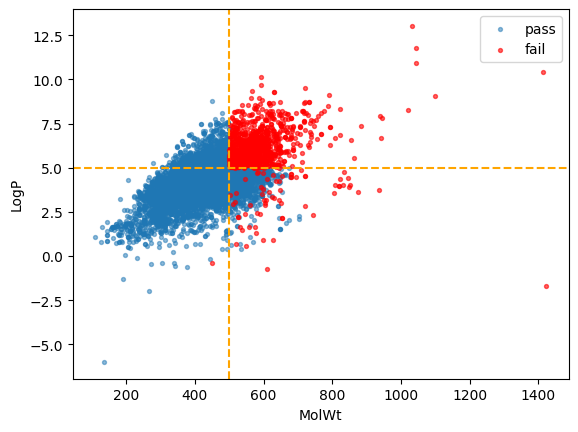

In [11]:
import matplotlib.pyplot as plt
ok = df.ro5_pass
plt.scatter(df.MolWt[ok],  df.LogP[ok],  s=8, alpha=.5, label="pass")
plt.scatter(df.MolWt[~ok], df.LogP[~ok], s=8, alpha=.6, c="red", label="fail")
plt.axvline(500, ls="--", c="orange") # the Lipinski's threshould
plt.axhline(5, ls="--", c="orange") # the Lipinski's threshould
plt.xlabel("MolWt"); plt.ylabel("LogP");
plt.legend();
plt.savefig('plot_scatter_MW_LogP.pdf')

From ~1,000 active molecules down to ~840 that are both drug-like and alert-free — a cleaner set
to search and model. **Filters are cheap; assays are expensive.** Removing obvious liabilities
early is how real campaigns avoid wasting effort.

## Recap
- **Active ≠ drug-like** — a good molecule also has to be absorbable and clean.
- **Rule of Five** flags poor oral-absorption profiles from four simple descriptors.
- **PAINS** alerts catch notorious assay-interfering substructures.
- We chained them into a funnel and saved the drug-like set.

**Next — Episode 5:** **similarity search** — take a known inhibitor and find look-alikes in our
set with Tanimoto + fingerprints.